---
title: "SSH 3: Edge States and the Wannier Connection"
subtitle: "Open Boundaries, Localized Modes, and a Representation Bridge"
artifact_status: "Exploratory beginner notebook; not canonical or supported"
---

# SSH 3: Edge States and the Wannier Connection

Notebooks 1 and 2 described the periodic bulk. This notebook opens the chain using the same cell convention. For $t_1<t_2$, the open chain begins and ends with weak $t_1$ bonds, and finite chains develop two states near zero energy that localize at the ends.

The calculation illustrates bulk--boundary correspondence for selected finite SSH examples. It does not establish a universal material claim. The final section connects the sequence conceptually to `bloch2wannier.ipynb` without reconstructing that notebook.

## Learning objectives

After this notebook, you should be able to compare open-chain spectra, identify finite-size edge modes, visualize their probability distribution, relate their splitting to chain length, and distinguish an edge-state calculation from a Wannier-basis construction.

As in the preceding notebooks, deterministic comparisons use the task-local absolute tolerance $10^{-10}$ with relative tolerance set to zero; finite-size threshold checks are stated only for their selected examples.


## 1. Open-chain spectra

We use the basis $(A_0,B_0,A_1,B_1,\ldots)$. The open Hamiltonian contains $t_1$ links inside cells and $t_2$ links between adjacent cells, but no link from the last cell back to the first.


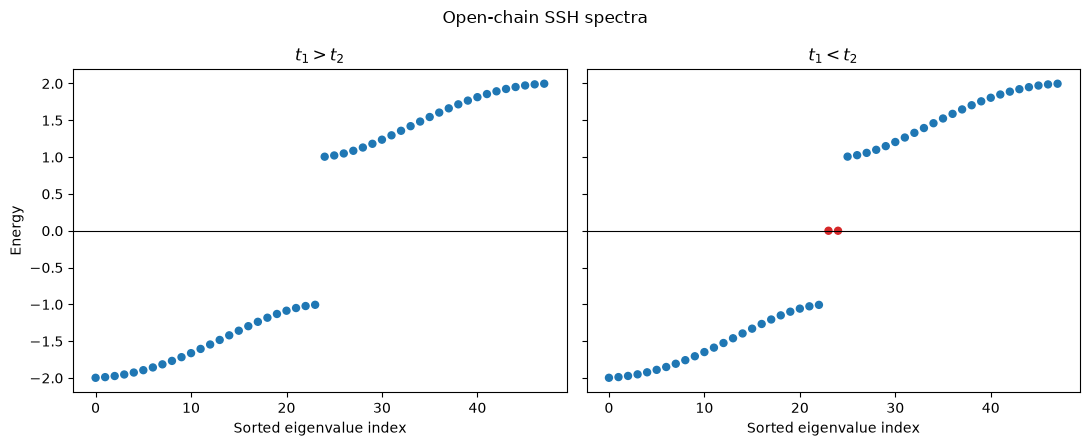

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose

ATOL = 1.0e-10


def ssh_open_hamiltonian(cells, t1, t2):
    H = np.zeros((2 * cells, 2 * cells), dtype=float)
    for r in range(cells):
        a_r, b_r = 2 * r, 2 * r + 1
        H[a_r, b_r] = H[b_r, a_r] = t1
        if r < cells - 1:
            a_next = 2 * (r + 1)
            H[b_r, a_next] = H[a_next, b_r] = t2
    return H

cells = 24
cases = [(1.5, 0.5, "$t_1>t_2$"), (0.5, 1.5, "$t_1<t_2$")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
spectra = {}
for ax, (t1, t2, title) in zip(axes, cases):
    H = ssh_open_hamiltonian(cells, t1, t2)
    assert_allclose(H, H.T, atol=ATOL, rtol=0.0)
    energies = np.linalg.eigvalsh(H)
    spectra[title] = energies
    colors = np.where(np.abs(energies) < ATOL, "tab:red", "tab:blue")
    ax.scatter(np.arange(2 * cells), energies, c=colors, s=25)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Sorted eigenvalue index")
axes[0].set_ylabel("Energy")
fig.suptitle("Open-chain SSH spectra")
fig.tight_layout()
plt.show()

assert np.min(np.abs(spectra["$t_1>t_2$"])) > 0.5
assert np.count_nonzero(np.abs(spectra["$t_1<t_2$"]) < ATOL) == 2


### Interpretation

The intracell-strong chain has no eigenvalue near zero. The intercell-strong chain has two numerically near-zero states, highlighted in red, because its weak-bond termination leaves one mode near each end. For finite chains the two modes can hybridize and split; the chosen length and hopping ratio make that splitting smaller than the task-local tolerance.


## 2. Where the near-zero modes live

An eigenvector gives amplitudes on all $2N$ sites. We sum the probabilities of the two eigenstates closest to zero. This combined density avoids choosing an arbitrary rotation within their nearly degenerate two-dimensional subspace.


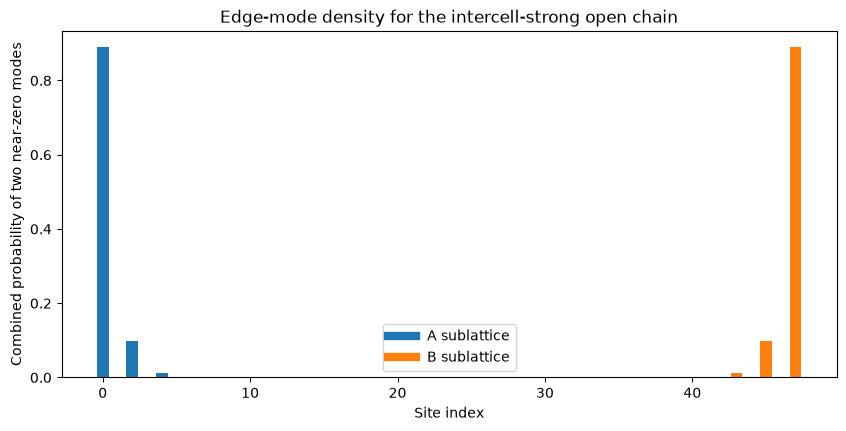

In [2]:
t1_top, t2_top = 0.5, 1.5
H_top = ssh_open_hamiltonian(cells, t1_top, t2_top)
energies, vectors = np.linalg.eigh(H_top)
edge_indices = np.argsort(np.abs(energies))[:2]
edge_vectors = vectors[:, edge_indices]
edge_density = np.sum(np.abs(edge_vectors) ** 2, axis=1)
assert_allclose(np.sum(edge_density), 2.0, atol=ATOL, rtol=0.0)

left_edge_weight = np.sum(edge_density[:4])
right_edge_weight = np.sum(edge_density[-4:])
assert left_edge_weight + right_edge_weight > 1.9

sites = np.arange(2 * cells)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(sites, edge_density, color=np.where(sites % 2 == 0, "tab:blue", "tab:orange"))
ax.set_xlabel("Site index")
ax.set_ylabel("Combined probability of two near-zero modes")
ax.set_title("Edge-mode density for the intercell-strong open chain")
ax.legend(handles=[
    plt.Line2D([0], [0], color="tab:blue", lw=6, label="A sublattice"),
    plt.Line2D([0], [0], color="tab:orange", lw=6, label="B sublattice"),
])
plt.show()


### Interpretation

Almost all combined probability lies within two unit cells (four site indices) of each boundary. The left and right profiles occupy opposite sublattices, as expected from the bipartite termination. The executable checks establish normalization and edge concentration for this finite example; they do not define a universal localization threshold.


## 3. Finite-size splitting

In a finite chain, left and right edge modes overlap. Their two energies therefore need not be exactly zero. Increasing the chain length reduces that overlap when $|t_1/t_2|<1$.


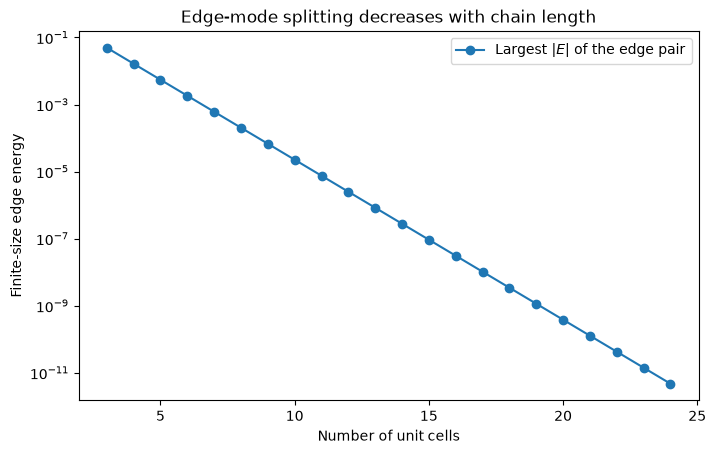

In [3]:
cell_counts = np.arange(3, 25)
splittings = []
for n_cells in cell_counts:
    energies = np.linalg.eigvalsh(ssh_open_hamiltonian(n_cells, t1_top, t2_top))
    closest = np.sort(np.abs(energies))[:2]
    splittings.append(np.max(closest))
splittings = np.array(splittings)
assert np.all(np.diff(splittings) < 0.0)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.semilogy(cell_counts, splittings, "o-", label="Largest $|E|$ of the edge pair")
ax.set_xlabel("Number of unit cells")
ax.set_ylabel("Finite-size edge energy")
ax.set_title("Edge-mode splitting decreases with chain length")
ax.legend()
plt.show()


### Interpretation

The edge-pair energy decreases monotonically over the selected lengths and appears approximately exponential on the logarithmic scale. The graph demonstrates finite-size hybridization in this parameter case; it does not assert an exact fitted decay law or a universal tolerance for zero energy.


## 4. Bulk winding and this boundary termination

For the chosen cell convention, $t_1<t_2$ has winding $\nu=1$. Cutting the periodic chain between cells leaves weak $t_1$ bonds at both ends, producing the observed edge pair. For $t_1>t_2$, the same cut does not leave an edge pair.


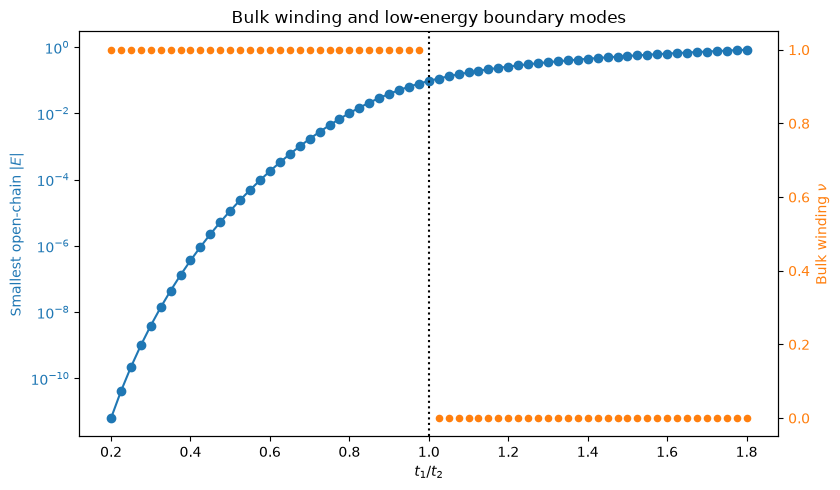

In [4]:
def bulk_winding(t1, t2):
    k = np.linspace(-np.pi, np.pi, 801)
    z = t1 + t2 * np.cos(k) + 1j * t2 * np.sin(k)
    if np.min(np.abs(z)) < ATOL:
        return np.nan
    angle = np.unwrap(np.angle(z))
    return (angle[-1] - angle[0]) / (2 * np.pi)

ratios = np.linspace(0.2, 1.8, 65)
windings = np.array([bulk_winding(r, 1.0) if not np.isclose(r, 1.0) else np.nan for r in ratios])
min_open_energies = np.array([
    np.min(np.abs(np.linalg.eigvalsh(ssh_open_hamiltonian(16, r, 1.0))))
    for r in ratios
])
assert_allclose(windings[ratios < 1.0], 1.0, atol=ATOL, rtol=0.0)
assert_allclose(windings[ratios > 1.0], 0.0, atol=ATOL, rtol=0.0)

fig, ax_e = plt.subplots(figsize=(8.5, 5))
ax_e.semilogy(ratios, min_open_energies, "o-", color="tab:blue", label="Smallest open-chain $|E|$")
ax_e.set_xlabel("$t_1/t_2$")
ax_e.set_ylabel("Smallest open-chain $|E|$", color="tab:blue")
ax_e.tick_params(axis="y", labelcolor="tab:blue")
ax_w = ax_e.twinx()
ax_w.scatter(ratios, windings, color="tab:orange", s=20, label="Bulk winding")
ax_w.set_ylabel("Bulk winding $\\nu$", color="tab:orange")
ax_w.tick_params(axis="y", labelcolor="tab:orange")
ax_e.axvline(1.0, color="black", linestyle=":")
ax_e.set_title("Bulk winding and low-energy boundary modes")
fig.tight_layout()
plt.show()


### Interpretation

On the intercell-strong side, the bulk winding is one and the finite open chain develops a very small boundary-mode energy away from the transition. On the intracell-strong side, the winding is zero and the lowest open-chain energy remains separated from zero at the bulk-band scale; it does not develop a near-zero in-gap mode. Near $t_1=t_2$, the bulk localization length grows and a short finite chain cannot sharply reproduce the infinite-system distinction. The statement depends on the displayed cell and termination conventions.


## 5. Connection to Bloch and Wannier representations

An edge-state calculation and a Wannier construction ask different questions. The SSH notebooks move between a real-space Hamiltonian, periodic Bloch fibers, a bulk winding, and an open-boundary spectrum. `bloch2wannier.ipynb` instead chooses an isolated Bloch band, fixes a gauge frame, and Fourier transforms that frame into a translated Wannier basis.


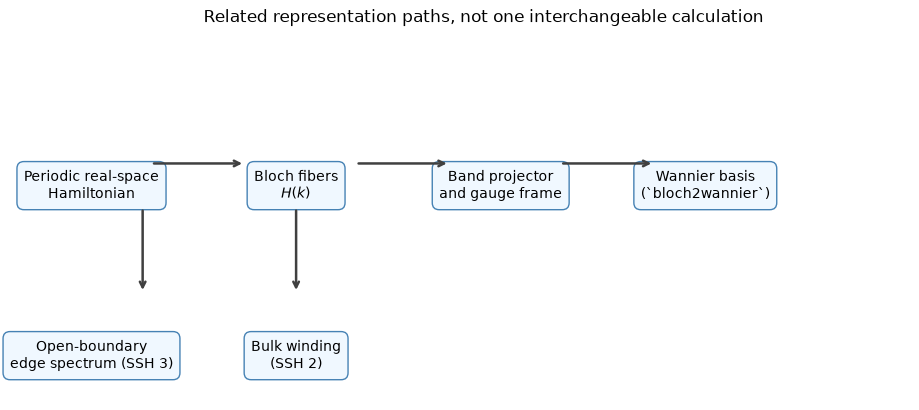

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.axis("off")
boxes = [
    (0.04, 0.58, "Periodic real-space\nHamiltonian"),
    (0.28, 0.58, "Bloch fibers\n$H(k)$"),
    (0.52, 0.58, "Band projector\nand gauge frame"),
    (0.76, 0.58, "Wannier basis\n(`bloch2wannier`)"),
    (0.28, 0.12, "Bulk winding\n(SSH 2)"),
    (0.04, 0.12, "Open-boundary\nedge spectrum (SSH 3)"),
]
for x, y, label in boxes:
    ax.text(x, y, label, ha="center", va="center", transform=ax.transAxes,
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "aliceblue", "edgecolor": "steelblue"})
arrow = {"arrowstyle": "->", "linewidth": 1.8, "color": "0.25"}
ax.annotate("", xy=(0.22, 0.64), xytext=(0.11, 0.64), xycoords=ax.transAxes, arrowprops=arrow)
ax.annotate("", xy=(0.46, 0.64), xytext=(0.35, 0.64), xycoords=ax.transAxes, arrowprops=arrow)
ax.annotate("", xy=(0.70, 0.64), xytext=(0.59, 0.64), xycoords=ax.transAxes, arrowprops=arrow)
ax.annotate("", xy=(0.28, 0.29), xytext=(0.28, 0.52), xycoords=ax.transAxes, arrowprops=arrow)
ax.annotate("", xy=(0.10, 0.29), xytext=(0.10, 0.52), xycoords=ax.transAxes, arrowprops=arrow)
ax.set_title("Related representation paths, not one interchangeable calculation")
plt.show()


### Interpretation

The upper route is the representation path leading toward Wannier functions. The lower boxes show two SSH diagnostics derived from bulk and open-boundary Hamiltonians. A localized SSH edge eigenstate is not the same object as a bulk Wannier function. This notebook supplies only a conceptual bridge; it neither modifies nor duplicates the accepted `bloch2wannier.ipynb` construction.


## Summary and limitations

For the displayed open termination, the intercell-strong SSH chain supports a pair of finite-size near-zero edge modes whose density is concentrated at opposite ends. Their splitting decreases with system size. This illustrates bulk--boundary correspondence under explicit model, cell, orientation, termination, and finite-size conventions.

The sequence excludes spin, interactions, disorder, Rice--Mele onsite staggering, many-body topology, material fitting, and physical-validation claims. Notebook execution and deterministic checks do not establish pedagogical validation, canonical status, lifecycle status, or support.
